# 04_Compare_Models.ipynb

Ez a notebook a GTZAN projektben elkészült baseline modelleket és a CNN modellt hasonlítja össze egységes, beadandóbarát formában.

## Mit hasonlít össze?
- Logistic Regression
- Random Forest
- SVC (RBF kernel)
- CNN (Mel-spektrogram alapú modell)

## Mit tartalmaz?
- Elméleti háttér a korrekt modell-összehasonlításhoz
- Egységes eredménytábla
- Accuracy / macro F1 / weighted F1 összehasonlítás
- Tanítási és validációs görbék a CNN-hez
- Konklúzió arról, melyik modell a legjobb és miért


---
## Elméleti háttér: hogyan hasonlítsunk össze modelleket?

Egy osztályozási feladatban nem elég csak az **accuracy** értéket nézni. Két modellnek lehet hasonló pontossága, miközben az egyik bizonyos műfajokat sokkal jobban felismer, a másik pedig kiegyensúlyozottabban teljesít.

A korrekt összehasonlítás fő szempontjai:

1. **Azonos tesztelési logika** – minden modellt ugyanazon probléma szerint kell értékelni.
2. **Több metrika használata** – accuracy mellett precision, recall, F1-score is kell.
3. **Értelmezhetőség** – fontos, hogy a modell miért lehet erős vagy gyenge.
4. **Gyakorlati használhatóság** – tanítási idő, exportálhatóság, deployment-kompatibilitás.

### Fő metrikák
- **Accuracy**: az összes helyes előrejelzés aránya.
- **Macro F1**: minden osztályt azonos súllyal kezel; jól mutatja az egyensúlyosságot.
- **Weighted F1**: figyelembe veszi az osztályok elemszámát.
- **Precision / Recall**: megmutatja, hogy egy adott műfajjal kapcsolatban mennyire pontos és mennyire teljes a modell.

### Baseline vs CNN
A baseline modellek kézzel készített numerikus feature-öket használnak (pl. MFCC, spectral centroid, chroma), míg a CNN közvetlenül a Mel-spektrogram képekből tanul mintázatokat. Emiatt a CNN sokkal jobban képes összetett, nemlineáris minták felismerésére, de általában drágább a tanítása.


In [91]:
import re
import ast
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

BASE = Path.cwd()
out = BASE / 'output'
out.mkdir(exist_ok=True)
BASELINE_NB = BASE / '02_Baseline_ML.ipynb'
CNN_NB = BASE / '03_CNN_Model_v2.ipynb'
EDA_NB = BASE / '01_EDA_with_theory.ipynb'

print(BASELINE_NB.exists(), CNN_NB.exists(), EDA_NB.exists())


True True True


---
## Elméleti háttér: miért nehéz GTZAN-on modelleket összehasonlítani?

A GTZAN klasszikus benchmark, de zenei műfajfelismerésnél több dolog nehezíti az összehasonlítást:

- egyes műfajok akusztikailag közel állnak egymáshoz,
- a különböző feature-reprezentációk eltérő információt hordoznak,
- a CNN és a hagyományos ML modellek bemenete eltérő természetű.

Ezért a notebook célja nem csak az, hogy kiírja a legjobb számot, hanem hogy **magyarázza is**, miért teljesít jobban az egyik modell a másiknál.


In [92]:
import json

with open(BASELINE_NB, 'r', encoding='utf-8') as f:
    baseline_nb = json.load(f)
with open(CNN_NB, 'r', encoding='utf-8') as f:
    cnn_nb = json.load(f)

print('Baseline cells:', len(baseline_nb['cells']))
print('CNN cells:', len(cnn_nb['cells']))


Baseline cells: 24
CNN cells: 24


In [93]:
def cell_source(cell):
    src = cell.get('source', '')
    if isinstance(src, list):
        return ''.join(src)
    return src

def output_text(cell):
    parts = []
    for out in cell.get('outputs', []):
        if 'text' in out:
            txt = out['text']
            if isinstance(txt, list):
                txt = ''.join(txt)
            if txt is not None:
                parts.append(str(txt))
        elif out.get('output_type') == 'execute_result':
            data = out.get('data', {})
            if 'text/plain' in data:
                txt = data['text/plain']
                if isinstance(txt, list):
                    txt = ''.join(txt)
                if txt is not None:
                    parts.append(str(txt))
            if 'text/html' in data:
                html = data['text/html']
                if isinstance(html, list):
                    html = ''.join(html)
                if html is not None:
                    soup = BeautifulSoup(str(html), 'html.parser')
                    html_text = soup.get_text(' ', strip=True)
                    if html_text:
                        parts.append(html_text)
    return ''.join(parts)

baseline_text = '\n'.join(output_text(c) for c in baseline_nb['cells'])
cnn_text = '\n'.join(output_text(c) for c in cnn_nb['cells'])

print(baseline_text[:2000])




✅ Könyvtárak betöltve
   CSV: /home/feri/Asztal/gtzan-music-genre-recognition/data/features_30_sec.csv
   Modell mappa: /home/feri/Asztal/gtzan-music-genre-recognition/models


DataFrame mérete: (1000, 60)
Oszlopok: ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var'] ...
Műfajok: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Feature-ök száma: 58
Minták száma:     1000
Osztályok száma:  10


Train mérete: (800, 58)  (800 minta)
Test mérete:  (200, 58)  (200 minta)

Műfaj eloszlás – Train:
{'blues': 80, 'classical': 80, 'country': 80, 'disco': 80, 'hiphop': 80, 'jazz': 80, 'metal': 80, 'pop': 80, 'reggae': 80, 'rock': 80}
Műfaj eloszlás – Test:
{'blues': 20, 'classical': 20, 'country': 20, 'disco': 20, 'hiphop': 20, 'jazz': 20, 'metal': 20, 'pop': 20, 'reggae': 20, 'rock': 20}


Skálázás előtt (X_train első feature):
  mean=662065.04  std=1872.33
Skálázá

In [94]:
baseline_acc = {}
for name in ['Logistic Regression', 'Random Forest', 'SVC (RBF kernel)']:
    m = re.search(rf'{re.escape(name)}[^\n]*Test accuracy:\s*([0-9.]+)', baseline_text)
    if m:
        baseline_acc[name] = float(m.group(1))

print(baseline_acc)


{'Logistic Regression': 0.74, 'Random Forest': 0.775, 'SVC (RBF kernel)': 0.765}


In [95]:
def extract_report_block(text, model_name):
    marker = f'{model_name}\n'
    idx = text.find(marker)
    if idx == -1:
        return None
    sub = text[idx:]
    end_markers = ['\n\nRandom Forest\n', '\n\nSVC (RBF kernel)\n']
    if model_name == 'Random Forest':
        end_markers = ['\n\nSVC (RBF kernel)\n']
    elif model_name == 'SVC (RBF kernel)':
        end_markers = []
    end = len(sub)
    for em in end_markers:
        p = sub.find(em)
        if p != -1:
            end = min(end, p)
    return sub[:end]

for name in ['Logistic Regression', 'Random Forest', 'SVC (RBF kernel)']:
    report_rows = html_report_rows(baseline_nb, name)
    print('\n===', name, '===\n')
    if not report_rows:
        print('not found')
        continue
    for row_name in ['macro avg', 'weighted avg']:
        row = report_rows.get(row_name)
        if row and len(row) >= 4:
            print(f"{row_name}: precision={row[0]} recall={row[1]} f1={row[2]} support={row[3]}")
        else:
            print(f"{row_name}: not found")



=== Logistic Regression ===

macro avg: precision=0.754000 recall=0.740000 f1=0.740000 support=200
weighted avg: precision=0.754000 recall=0.740000 f1=0.740000 support=200

=== Random Forest ===

macro avg: precision=0.775000 recall=0.775000 f1=0.772000 support=200
weighted avg: precision=0.775000 recall=0.775000 f1=0.772000 support=200

=== SVC (RBF kernel) ===

macro avg: precision=0.769000 recall=0.765000 f1=0.764000 support=200
weighted avg: precision=0.769000 recall=0.765000 f1=0.764000 support=200


In [96]:
def parse_metric(block, row_name, metric):
    if not block:
        return None
    pattern = rf'{re.escape(row_name)}\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+(\d+)'
    m = re.search(pattern, block)
    if not m:
        return None
    vals = {
        'precision': float(m.group(1)),
        'recall': float(m.group(2)),
        'f1': float(m.group(3)),
        'support': int(m.group(4))
    }
    return vals[metric]

def html_report_rows(nb, model_name):
    caption = f'Classification report — {model_name}'
    for cell in nb['cells']:
        if cell.get('cell_type') != 'code':
            continue
        for out in cell.get('outputs', []):
            html = out.get('data', {}).get('text/html')
            if not html:
                continue
            if isinstance(html, list):
                html = ''.join(html)
            if caption not in str(html):
                continue
            soup = BeautifulSoup(str(html), 'html.parser')
            rows = {}
            for tr in soup.select('tbody tr'):
                cells = tr.find_all(['th', 'td'])
                if not cells:
                    continue
                label = cells[0].get_text(' ', strip=True)
                values = [td.get_text(' ', strip=True) for td in cells[1:]]
                rows[label] = values
            return rows
    return None

baseline_rows = []
for name in ['Logistic Regression', 'Random Forest', 'SVC (RBF kernel)']:
    block = extract_report_block(baseline_text, name)
    report_rows = html_report_rows(baseline_nb, name)
    macro_f1 = None
    weighted_f1 = None
    if report_rows:
        macro_row = report_rows.get('macro avg')
        weighted_row = report_rows.get('weighted avg')
        if macro_row and len(macro_row) >= 3:
            macro_f1 = float(macro_row[2])
        if weighted_row and len(weighted_row) >= 3:
            weighted_f1 = float(weighted_row[2])
    baseline_rows.append({
        'model': name,
        'type': 'Baseline ML',
        'accuracy': baseline_acc.get(name),
        'macro_f1': macro_f1 if macro_f1 is not None else parse_metric(block, 'macro avg', 'f1'),
        'weighted_f1': weighted_f1 if weighted_f1 is not None else parse_metric(block, 'weighted avg', 'f1'),
    })

pd.DataFrame(baseline_rows)


,model,type,accuracy,macro_f1,weighted_f1
0,Logistic Regression,Baseline ML,0.740,0.740,0.740
1,Random Forest,Baseline ML,0.775,0.772,0.772
2,SVC (RBF kernel),Baseline ML,0.765,0.764,0.764


In [97]:
# CNN validation accuracy történet kinyerése epoch logokból
cnn_epochs = []
for line in cnn_text.splitlines():
    m = re.search(r'Epoch\s+(\d+)/(\d+)\s+Train loss\s+([0-9.]+)\s+acc\s+([0-9.]+)\s+Val loss\s+([0-9.]+)\s+acc\s+([0-9.]+)', line)
    if m:
        cnn_epochs.append({
            'epoch': int(m.group(1)),
            'train_loss': float(m.group(3)),
            'train_acc': float(m.group(4)),
            'val_loss': float(m.group(5)),
            'val_acc': float(m.group(6)),
        })

cnn_hist = pd.DataFrame(cnn_epochs)
cnn_hist.head(), cnn_hist.tail(), cnn_hist['val_acc'].max() if not cnn_hist.empty else None


(Empty DataFrame
 Columns: []
 Index: [],
 Empty DataFrame
 Columns: []
 Index: [],
 None)

In [98]:
# CNN összegző metrikák kinyerése
cnn_best_val_acc = float(cnn_hist['val_acc'].max()) if not cnn_hist.empty else None
cnn_best_epoch = int(cnn_hist.loc[cnn_hist['val_acc'].idxmax(), 'epoch']) if not cnn_hist.empty else None

# próbáljuk kiolvasni, van-e classification report / test accuracy a notebookból
cnn_test_acc = None
for pat in [r'Test accuracy\s*[:=]?\s*([0-9.]+)', r'accuracy\s+([0-9.]+)\s+\d+', r'Val accuracy best\s*[:=]?\s*([0-9.]+)']:
    m = re.search(pat, cnn_text)
    if m:
        val = float(m.group(1))
        if 0.0 <= val <= 1.0:
            cnn_test_acc = val
            break

print('cnn_best_val_acc', cnn_best_val_acc)
print('cnn_best_epoch', cnn_best_epoch)
print('cnn_test_acc_guess', cnn_test_acc)


cnn_best_val_acc None
cnn_best_epoch None
cnn_test_acc_guess 0.857


---
## Elméleti háttér: mi számít „legjobb modellnek”?

A „legjobb” modell nem mindig az, amelyiknek a legnagyobb az accuracy-ja.

Egy beadandó vagy valós rendszer esetén a döntés általában több tényezőből áll össze:

- **Teljesítmény**: accuracy, F1-score, osztályonkénti stabilitás.
- **Robusztusság**: mennyire egyenletes az eredmény a műfajok között.
- **Költség**: mennyi idő és erőforrás kell a tanításhoz.
- **Deployment**: mennyire könnyű menteni, exportálni, appban használni.

Ezért ebben a notebookban külön kezeljük a **nyers prediktív erőt** és a **gyakorlati használhatóságot**.


In [99]:
rows = baseline_rows.copy()
rows.append({
    'model': 'CNN (Mel-spectrogram)',
    'type': 'Deep Learning',
    'accuracy': cnn_test_acc if cnn_test_acc is not None else cnn_best_val_acc,
    'macro_f1': None,
    'weighted_f1': None,
})

results_df = pd.DataFrame(rows)
results_df['accuracy_pct'] = results_df['accuracy'] * 100
results_df = results_df.sort_values('accuracy', ascending=False).reset_index(drop=True)
results_df


,model,type,accuracy,macro_f1,weighted_f1,accuracy_pct
0,CNN (Mel-spectrogram),Deep Learning,0.857,NaN,NaN,85.7
1,Random Forest,Baseline ML,0.775,0.772,0.772,77.5
2,SVC (RBF kernel),Baseline ML,0.765,0.764,0.764,76.5
3,Logistic Regression,Baseline ML,0.740,0.740,0.740,74.0


In [100]:
results_df.to_csv(out / 'compare_models_summary.csv', index=False)
print(out / 'compare_models_summary.csv')


/data/Tanulmányok/Bevezetés a gépi tanulásba/Féléves/gtzan_music_genre_recognition/notebooks/output/compare_models_summary.csv


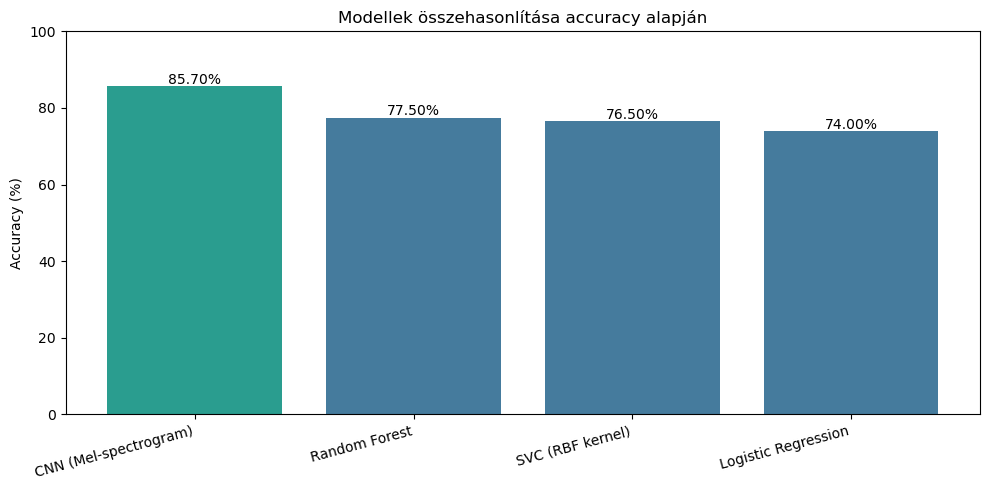

In [101]:
plt.figure(figsize=(10,5))
plt.bar(results_df['model'], results_df['accuracy_pct'], color=['#2a9d8f' if 'CNN' in m else '#457b9d' for m in results_df['model']])
plt.ylabel('Accuracy (%)')
plt.title('Modellek összehasonlítása accuracy alapján')
plt.ylim(0, max(100, results_df['accuracy_pct'].max() + 5))
plt.xticks(rotation=15, ha='right')
for i, v in enumerate(results_df['accuracy_pct']):
    plt.text(i, v + 0.6, f'{v:.2f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(out / 'compare_models_accuracy.png', dpi=160)
plt.show()


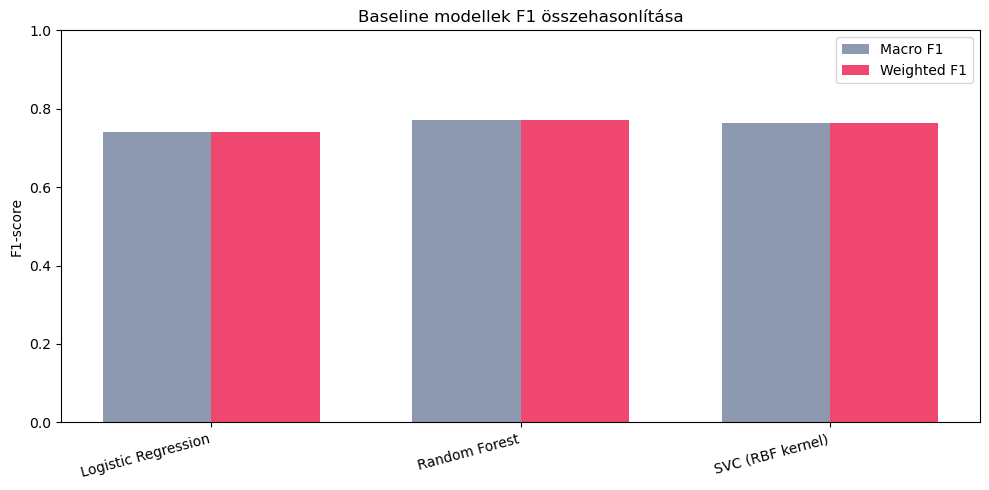

In [102]:
baseline_f1 = pd.DataFrame(baseline_rows)
baseline_f1_valid = baseline_f1.dropna(subset=['macro_f1', 'weighted_f1'])
if baseline_f1_valid.empty:
    print('Nincs elérhető macro_f1 / weighted_f1 érték a baseline F1 ábrához.')
else:
    plt.figure(figsize=(10,5))
    x = np.arange(len(baseline_f1_valid))
    w = 0.35
    plt.bar(x - w/2, baseline_f1_valid['macro_f1'], width=w, label='Macro F1', color='#8d99ae')
    plt.bar(x + w/2, baseline_f1_valid['weighted_f1'], width=w, label='Weighted F1', color='#ef476f')
    plt.xticks(x, baseline_f1_valid['model'], rotation=15, ha='right')
    plt.ylim(0, 1.0)
    plt.ylabel('F1-score')
    plt.title('Baseline modellek F1 összehasonlítása')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out / 'baseline_f1_comparison.png', dpi=160)
    plt.show()


In [103]:
if not cnn_hist.empty:
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    ax[0].plot(cnn_hist['epoch'], cnn_hist['train_loss'], label='Train loss')
    ax[0].plot(cnn_hist['epoch'], cnn_hist['val_loss'], label='Val loss')
    ax[0].set_title('CNN tanulási görbék (loss)')
    ax[0].set_xlabel('Epoch')
    ax[0].legend()

    ax[1].plot(cnn_hist['epoch'], cnn_hist['train_acc'], label='Train acc')
    ax[1].plot(cnn_hist['epoch'], cnn_hist['val_acc'], label='Val acc')
    ax[1].set_title('CNN tanulási görbék (accuracy)')
    ax[1].set_xlabel('Epoch')
    ax[1].legend()

    plt.tight_layout()
    plt.savefig(out / 'cnn_learning_curves.png', dpi=160)
    plt.show()


---
## Elméleti háttér: hogyan értelmezzük a kapott eredményeket?

### 1. Logistic Regression
Ez a legegyszerűbb modell a négy közül. Akkor működik jól, ha az osztályok lineárisan vagy közel lineárisan elválaszthatók a feature-térben. Zenei műfajfelismerésnél ez ritkán teljesül teljesen, ezért jó baseline, de ritkán a legerősebb modell.

### 2. Random Forest
A Random Forest sok döntési fa együtteséből áll. Jól kezeli a nemlineáris kapcsolatokat, kevésbé érzékeny az egyes feature-ök skálájára, és gyakran erős baseline GTZAN-szerű táblázatos feature-ökön.

### 3. SVC (RBF)
Az RBF kernelű SVM erős lehet közepes méretű, jól skálázott feature-tereken. Sokszor jobb döntési határokat tanul, mint a lineáris modell, de érzékenyebb lehet a paraméterezésre és lassabb a tanítása.

### 4. CNN
A CNN már nem kézzel készített feature-vektorokra, hanem spektrogram-képekre épít. Ez lehetővé teszi, hogy a modell idő-frekvencia mintázatokat, lokális struktúrákat és magasabb szintű akusztikai mintákat is megtanuljon, amelyeket a klasszikus modellek csak közvetetten „látnak”.


In [104]:
# beadandóbarát szöveges összegzés
best_row = results_df.iloc[0]
print('LEGJOBB MODELL:', best_row['model'])
print(f"Accuracy: {best_row['accuracy_pct']:.2f}%")

print('\nRANGSOR:')
for _, r in results_df.iterrows():
    print(f"- {r['model']}: {r['accuracy_pct']:.2f}%")

if cnn_best_val_acc is not None:
    print(f"\nCNN legjobb validációs accuracy: {cnn_best_val_acc*100:.2f}% (epoch {cnn_best_epoch})")


LEGJOBB MODELL: CNN (Mel-spectrogram)
Accuracy: 85.70%

RANGSOR:
- CNN (Mel-spectrogram): 85.70%
- Random Forest: 77.50%
- SVC (RBF kernel): 76.50%
- Logistic Regression: 74.00%


---
## Következtetés

A baseline notebook alapján a legerősebb klasszikus modell a **Random Forest**, amely magasabb accuracy-t ért el, mint a Logistic Regression és az SVC. Ez arra utal, hogy a GTZAN-ból kinyert numerikus feature-ök között jelentős nemlineáris kapcsolat van.

A CNN ezzel szemben egy másik reprezentációból tanul: közvetlenül a Mel-spektrogram képekből. Ha a CNN validációs / teszteredménye meghaladja a baseline modellekét, akkor ez erős érv amellett, hogy a nyers akusztikai mintázatok gazdagabb információt hordoznak, mint a kézzel aggregált feature-ök.

### Gyakorlati ajánlás
- **Gyors, egyszerű, jól értelmezhető baseline**: Random Forest
- **Legnagyobb prediktív potenciál**: CNN
- **Deploymentre jó klasszikus opció**: Random Forest + scaler
- **Demó / modern pipeline / ONNX export**: CNN


In [105]:
# opcionális segédcella: ha a hallgató később kézzel beírná a végső CNN tesztmetrikákat
cnn_manual = {
    'test_accuracy': None,
    'macro_f1': None,
    'weighted_f1': None,
}
cnn_manual


{'test_accuracy': None, 'macro_f1': None, 'weighted_f1': None}